In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans

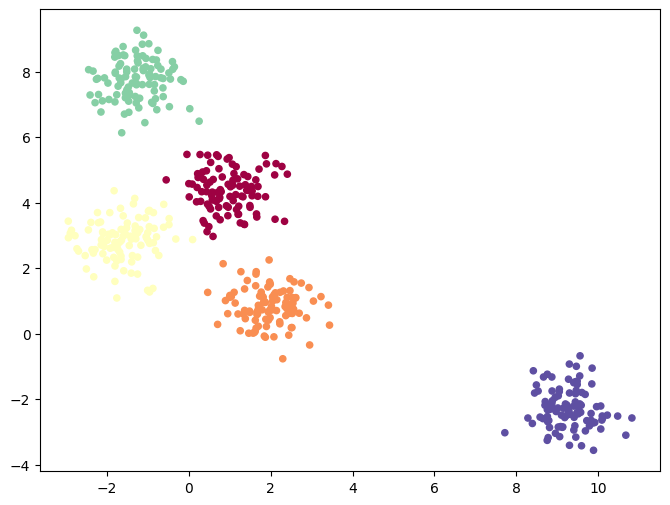

In [2]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val) for val in np.linspace(0, 1, len(set(y)))])

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)    

Elbow method

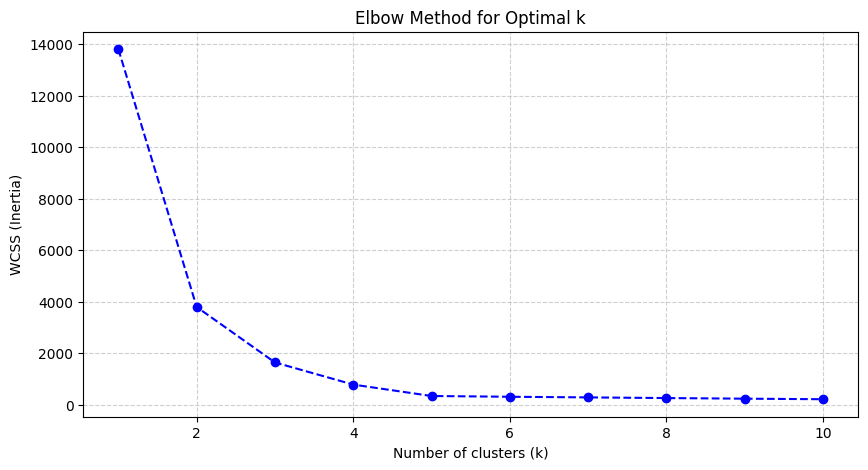

In [4]:
wcss = []
K_range = range(1, 11)
for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Agglomerative clustering (Complete Linkage)

In [5]:
optimal_k = 5

agg_complete = AgglomerativeClustering(n_clusters=optimal_k, linkage='complete')
labels_complete = agg_complete.fit_predict(X)

Agglomerative clustering (Single Linkage)

In [6]:
agg_single = AgglomerativeClustering(n_clusters=optimal_k, linkage='single')
labels_single = agg_single.fit_predict(X)

DBSCAN

In [7]:
dbscan = DBSCAN(eps=0.7, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

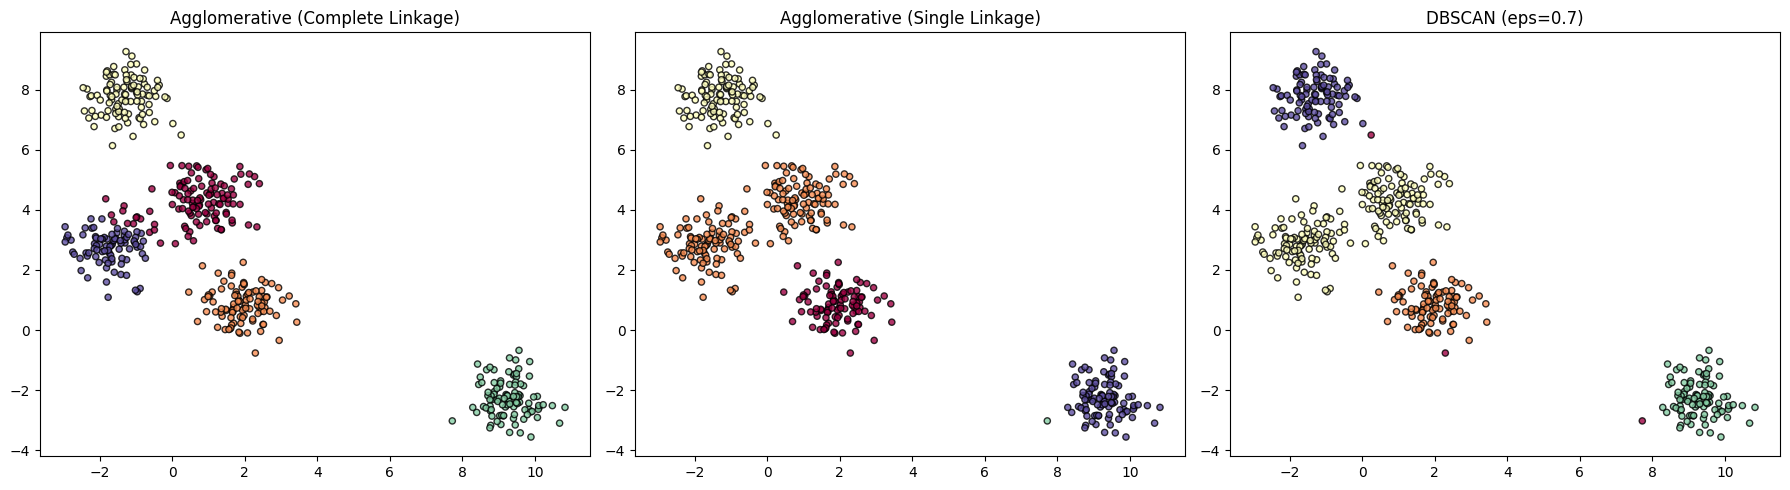

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Complete Linkage
axes[0].scatter(X[:, 0], X[:, 1], c=labels_complete, cmap='Spectral', s=20, edgecolor='k', alpha=0.8)
axes[0].set_title('Agglomerative (Complete Linkage)')

#Single Linkage
axes[1].scatter(X[:, 0], X[:, 1], c=labels_single, cmap='Spectral', s=20, edgecolor='k', alpha=0.8)
axes[1].set_title('Agglomerative (Single Linkage)')

#DBSCAN
scatter = axes[2].scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='Spectral', s=20, edgecolor='k', alpha=0.8)
axes[2].set_title(f'DBSCAN (eps=0.7)')

plt.tight_layout()
plt.show()